In [78]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from backtesting import Backtest, Strategy
from backtesting.lib import crossover
from backtesting.test import SMA, GOOG
import warnings
warnings.filterwarnings('ignore')

In [79]:
# Define the model architectures (matching the trained models)
class StockPredictorNN(nn.Module):
    """
    Feed-Forward Neural Network for Stock Price Prediction
    """
    def __init__(self, input_features=48, hidden_layers=[256, 128, 64], dropout=0.3):
        super(StockPredictorNN, self).__init__()
        
        layers = []
        prev_size = input_features
        
        # Input layer with batch normalization
        layers.extend([
            nn.Linear(prev_size, hidden_layers[0]),
            nn.BatchNorm1d(hidden_layers[0]),
            nn.ReLU(),
            nn.Dropout(dropout)
        ])
        prev_size = hidden_layers[0]
        
        # Hidden layers
        for hidden_size in hidden_layers[1:]:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size
        
        # Output layer (regression)
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            module.bias.data.fill_(0.01)
    
    def forward(self, x):
        return self.network(x)

class StockLSTM(nn.Module):
    """
    LSTM Network for Time Series Stock Prediction
    Uses sequence of past days to predict next day
    """
    def __init__(self, input_features=48, hidden_size=128, num_layers=2, dropout=0.2):
        super(StockLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers with dropout
        self.lstm = nn.LSTM(
            input_features, 
            hidden_size, 
            num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        
        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
            nn.Softmax(dim=1)
        )
        
        # Output layers
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, features)
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Apply attention to focus on important time steps
        attention_weights = self.attention(lstm_out)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)
        
        # Final prediction
        output = self.classifier(context_vector)
        return output

class HybridStockNet(nn.Module):
    """
    Hybrid Architecture combining CNN and LSTM
    CNN extracts patterns, LSTM captures temporal dependencies
    """
    def __init__(self, input_features=48, cnn_channels=[64, 32], lstm_hidden=64):
        super(HybridStockNet, self).__init__()
        
        # 1D CNN for pattern extraction
        self.conv1 = nn.Conv1d(1, cnn_channels[0], kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(cnn_channels[0], cnn_channels[1], kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(input_features // 2)
        
        # LSTM for temporal modeling
        self.lstm = nn.LSTM(cnn_channels[1], lstm_hidden, batch_first=True)
        
        # Final layers
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x shape: (batch_size, features) -> (batch_size, 1, features)
        x = x.unsqueeze(1)
        
        # CNN feature extraction
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        
        # Reshape for LSTM: (batch_size, seq_len, features)
        x = x.transpose(1, 2)
        
        # LSTM processing
        lstm_out, _ = self.lstm(x)
        
        # Use last output
        x = lstm_out[:, -1, :]
        
        # Final prediction
        return self.fc(x)

In [80]:
# Load the trained models
def load_models():
    # Initialize models
    lstm_model = StockLSTM()
    nn_model = StockPredictorNN()
    hybrid_model = HybridStockNet()
    
    # Load the trained weights
    lstm_model.load_state_dict(torch.load('best_stocklstm_model.pth', map_location='cpu'))
    nn_model.load_state_dict(torch.load('best_stockpredictornn_model.pth', map_location='cpu'))
    hybrid_model.load_state_dict(torch.load('best_hybridstocknet_model.pth', map_location='cpu'))
    
    # Set to evaluation mode
    lstm_model.eval()
    nn_model.eval()
    hybrid_model.eval()
    
    return lstm_model, nn_model, hybrid_model

# Load models
lstm_model, nn_model, hybrid_model = load_models()
print("All models loaded successfully!")

All models loaded successfully!


In [81]:
# Enhanced Stock Prediction Strategy with Model Predictions
class MLPredictionStrategy(Strategy):
    """
    Trading strategy that uses ML model predictions to make buy/sell decisions
    """
    def __init__(self, model, model_name, feature_scaler=None, target_scaler=None):
        self.model = model
        self.model_name = model_name
        self.feature_scaler = feature_scaler
        self.target_scaler = target_scaler
        self.lookback = 20  # Days of data needed for features
        
    def init(self):
        # Technical indicators
        self.sma_10 = self.I(SMA, self.data.Close, 10)
        self.sma_20 = self.I(SMA, self.data.Close, 20)
        self.sma_50 = self.I(SMA, self.data.Close, 50)
        
        # RSI
        def rsi(close, period=14):
            delta = pd.Series(close).diff()
            gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
            rs = gain / loss
            return 100 - (100 / (1 + rs))
        
        self.rsi = self.I(rsi, self.data.Close, 14)
        
        # Bollinger Bands
        def bb_upper(close, period=20, std=2):
            sma = pd.Series(close).rolling(window=period).mean()
            std_dev = pd.Series(close).rolling(window=period).std()
            return sma + (std * std_dev)
        
        def bb_lower(close, period=20, std=2):
            sma = pd.Series(close).rolling(window=period).mean()
            std_dev = pd.Series(close).rolling(window=period).std()
            return sma - (std * std_dev)
        
        self.bb_upper = self.I(bb_upper, self.data.Close, 20)
        self.bb_lower = self.I(bb_lower, self.data.Close, 20)
        
        # Volume indicators
        def volume_sma(volume, period=10):
            return pd.Series(volume).rolling(window=period).mean()
        
        self.volume_sma = self.I(volume_sma, self.data.Volume, 10)
        
    def create_features(self, i):
        """Create features for model prediction at index i"""
        if i < self.lookback:
            return None
            
        # Get recent data
        close_prices = self.data.Close[i-self.lookback:i+1]
        high_prices = self.data.High[i-self.lookback:i+1]
        low_prices = self.data.Low[i-self.lookback:i+1]
        open_prices = self.data.Open[i-self.lookback:i+1]
        volumes = self.data.Volume[i-self.lookback:i+1]
        
        # Create feature array (simplified version of your features)
        features = []
        
        # Price features
        features.extend([
            close_prices[-1], high_prices[-1], low_prices[-1], open_prices[-1],
            (high_prices[-1] - low_prices[-1]) / close_prices[-1],  # Volatility
            volumes[-1] / np.mean(volumes),  # Volume ratio
        ])
        
        # Technical indicators
        sma_10_val = self.sma_10[i] if i < len(self.sma_10) else close_prices[-1]
        sma_20_val = self.sma_20[i] if i < len(self.sma_20) else close_prices[-1]
        sma_50_val = self.sma_50[i] if i < len(self.sma_50) else close_prices[-1]
        rsi_val = self.rsi[i] if i < len(self.rsi) else 50
        
        features.extend([
            sma_10_val / close_prices[-1] - 1,  # SMA ratio
            sma_20_val / close_prices[-1] - 1,
            sma_50_val / close_prices[-1] - 1,
            rsi_val / 100,  # Normalized RSI
        ])
        
        # Price momentum features
        returns = np.diff(close_prices) / close_prices[:-1]
        features.extend([
            np.mean(returns[-5:]),  # 5-day return
            np.mean(returns[-10:]),  # 10-day return
            np.std(returns[-10:]),   # 10-day volatility
            np.max(returns[-5:]),    # Max recent return
            np.min(returns[-5:]),    # Min recent return
        ])
        
        # Pad features to match model input size (48 features expected)
        while len(features) < 48:
            features.append(0.0)
        
        return np.array(features[:48], dtype=np.float32)
    
    def get_prediction(self, i):
        """Get model prediction for current timestep"""
        features = self.create_features(i)
        if features is None:
            return 0.0
            
        try:
            with torch.no_grad():
                if self.model_name == 'LSTM':
                    # For LSTM, we need sequence data
                    # Create a simple sequence by repeating features
                    features_tensor = torch.FloatTensor(features).unsqueeze(0).unsqueeze(0)
                    features_tensor = features_tensor.expand(-1, 10, -1)  # seq_len=10
                    prediction = self.model(features_tensor).item()
                elif self.model_name == 'Hybrid':
                    # For Hybrid model, use regular features
                    features_tensor = torch.FloatTensor(features).unsqueeze(0)
                    prediction = self.model(features_tensor).item()
                else:
                    # For regular NN
                    features_tensor = torch.FloatTensor(features).unsqueeze(0)
                    prediction = self.model(features_tensor).item()
                    
            return prediction
        except Exception as e:
            print(f"Prediction error: {e}")
            return 0.0
    
    def next(self):
        # Get current index
        current_idx = len(self.data) - len(self.data.Close) + len([x for x in self.data.Close if not pd.isna(x)]) - 1
        
        # Skip if not enough data
        if current_idx < self.lookback:
            return
            
        # Get model prediction
        prediction = self.get_prediction(current_idx)
        
        # Trading logic based on prediction and technical indicators
        current_price = self.data.Close[-1]
        
        # Strong buy signal: positive prediction + bullish technicals
        if (prediction > 0.02 and  # Positive prediction threshold
            self.data.Close[-1] > self.sma_10[-1] and  # Price above short-term SMA
            self.rsi[-1] < 70 and  # Not overbought
            not self.position):
            
            self.buy(size=0.95)  # Use 95% of available cash
            
        # Strong sell signal: negative prediction + bearish technicals
        elif (prediction < -0.02 and  # Negative prediction threshold
              self.data.Close[-1] < self.sma_10[-1] and  # Price below short-term SMA
              self.rsi[-1] > 30 and  # Not oversold
              self.position):
            
            self.position.close()
            
        # Stop loss and take profit
        elif self.position:
            try:
                # Use the correct attribute name for entry price
                entry_price = self.position.entry_price if hasattr(self.position, 'entry_price') else self.position.entry_bar.Close
                current_return = (current_price - entry_price) / entry_price
                
                # Stop loss at -5%
                if current_return < -0.05:
                    self.position.close()
                    
                # Take profit at +10%
                elif current_return > 0.10:
                    self.position.close()
            except (AttributeError, TypeError):
                # If we can't get entry price, just use basic risk management
                pass

# Download test data for backtesting
def get_stock_data(symbol, start_date, end_date):
    """Download stock data for backtesting"""
    try:
        data = yf.download(symbol, start=start_date, end=end_date)
        
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = [col[0] for col in data.columns]

        required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
        if all(col in data.columns for col in required_cols):
            data = data[required_cols]  # Reorder to OHLCV
        
        data = data.dropna()
        return data
    except Exception as e:
        print(f"Error downloading {symbol}: {e}")
        return None

# Backtesting configuration
INITIAL_CASH = 10000  # $10,000 starting capital
COMMISSION = 0.002    # 0.2% per transaction
START_DATE = '2023-01-01'
END_DATE = '2024-12-31'

# Test stocks (popular stocks for backtesting)
test_stocks = ['AAPL', 'GOOGL', 'MSFT', 'TSLA', 'NVDA']

print("🚀 Starting Backtesting with 3 ML Models")
print("=" * 50)
print(f"💰 Initial Capital: ${INITIAL_CASH:,}")
print(f"📅 Period: {START_DATE} to {END_DATE}")
print(f"📊 Commission: {COMMISSION*100}% per trade")
print(f"🎯 Test Stocks: {', '.join(test_stocks)}")
print("=" * 50)

# Store results
backtest_results = {}
model_names = ['FeedForward', 'LSTM', 'Hybrid']
models = [nn_model, lstm_model, hybrid_model]

for stock in test_stocks:
    print(f"\n📈 Backtesting {stock}...")
    
    # Download data
    stock_data = get_stock_data(stock, START_DATE, END_DATE)
    if stock_data is None or len(stock_data) < 100:
        print(f"❌ Insufficient data for {stock}")
        continue
    
    backtest_results[stock] = {}
    
    # Test each model
    for model, model_name in zip(models, model_names):
        print(f"  🤖 Testing {model_name} model...")
        
        try:
            # Fix: Use a factory function to properly capture variables
            def create_strategy_class(captured_model, captured_name):
                class CurrentModelStrategy(MLPredictionStrategy):
                    def __init__(self, broker, data, params):
                        # Call Strategy.__init__ first to set up data access
                        Strategy.__init__(self, broker, data, params)
                        # Then set our custom attributes
                        self.model = captured_model
                        self.model_name = captured_name
                        self.feature_scaler = None
                        self.target_scaler = None
                        self.lookback = 20
                return CurrentModelStrategy
            
            # Create the strategy class with current loop variables
            StrategyClass = create_strategy_class(model, model_name)
            
            # OHLCV format
            # Run backtest
            bt = Backtest(
                stock_data, 
                StrategyClass,
                cash=INITIAL_CASH,
                commission=COMMISSION,
                exclusive_orders=True # VERY BAD (Cant have more than one position)
                # trade_on_close??
            )
            
            result = bt.run()
            bt.plot()
            
            # Store results
            backtest_results[stock][model_name] = {
                'Final Value': result['Equity Final [$]'],
                'Total Return': result['Return [%]'],
                'Sharpe Ratio': result['Sharpe Ratio'],
                'Max Drawdown': result['Max. Drawdown [%]'],
                'Total Trades': result['# Trades'],
                'Win Rate': result['Win Rate [%]'] if result['# Trades'] > 0 else 0,
                'Volatility': result['Volatility [%]']
            }
            
            print(f"    ✅ Return: {result['Return [%]']:.2f}% | Sharpe: {result['Sharpe Ratio']:.2f} | Trades: {result['# Trades']}")
            
        except Exception as e:
            print(f"    ❌ Error with {model_name}: {e}")
            backtest_results[stock][model_name] = None

print("\n🎉 Backtesting Complete!")
print("=" * 50)

[*********************100%***********************]  1 of 1 completed

🚀 Starting Backtesting with 3 ML Models
💰 Initial Capital: $10,000
📅 Period: 2023-01-01 to 2024-12-31
📊 Commission: 0.2% per trade
🎯 Test Stocks: AAPL, GOOGL, MSFT, TSLA, NVDA

📈 Backtesting AAPL...
  🤖 Testing FeedForward model...


Backtest.run:   0%|          | 0/451 [00:00<?, ?bar/s]

    ❌ Error with FeedForward: Invalid frequency: ME
  🤖 Testing LSTM model...


Backtest.run:   0%|          | 0/451 [00:00<?, ?bar/s]

...

    ❌ Error with FeedForward: Invalid frequency: ME
  🤖 Testing LSTM model...


Backtest.run:   0%|          | 0/451 [00:00<?, ?bar/s]

    ❌ Error with LSTM: Invalid frequency: ME
  🤖 Testing Hybrid model...


Backtest.run:   0%|          | 0/451 [00:00<?, ?bar/s]

    ❌ Error with Hybrid: Invalid frequency: ME

🎉 Backtesting Complete!


In [82]:
# Simplified Backtesting Implementation
class SimpleMLStrategy(Strategy):
    """Simplified ML trading strategy"""
    
    model = None
    model_name = ""
    
    def init(self):
        # Simple moving averages
        self.sma_fast = self.I(SMA, self.data.Close, 10)
        self.sma_slow = self.I(SMA, self.data.Close, 20)
        
    def get_simple_prediction(self, index):
        """Get prediction using simple features"""
        if index < 20:  # Need enough history
            return 0.0
            
        # Create simple features from recent price action
        recent_closes = self.data.Close[max(0, index-20):index+1]
        if len(recent_closes) < 5:
            return 0.0
            
        # Simple features: recent returns, moving averages, etc.
        features = []
        
        # Price features
        current_price = recent_closes[-1]
        features.extend([
            current_price,
            np.mean(recent_closes[-5:]),  # 5-day avg
            np.mean(recent_closes[-10:]), # 10-day avg
            np.std(recent_closes[-10:]),  # volatility
        ])
        
        # Return features
        if len(recent_closes) > 1:
            returns = np.diff(recent_closes) / recent_closes[:-1]
            features.extend([
                np.mean(returns[-5:]),    # 5-day avg return
                np.mean(returns[-10:]),   # 10-day avg return
                np.std(returns),          # return volatility
                returns[-1] if len(returns) > 0 else 0,  # last return
            ])
        else:
            features.extend([0, 0, 0, 0])
        
        # Technical indicator ratios
        sma_fast = np.mean(recent_closes[-10:])
        sma_slow = np.mean(recent_closes[-20:])
        features.extend([
            current_price / sma_fast - 1,  # Price vs fast SMA
            sma_fast / sma_slow - 1,       # Fast vs slow SMA
        ])
        
        # Pad to 48 features (expected by models)
        while len(features) < 48:
            features.append(0.0)
            
        features = np.array(features[:48], dtype=np.float32)
        
        try:
            with torch.no_grad():
                if self.model_name == 'LSTM':
                    # Create sequence for LSTM
                    features_tensor = torch.FloatTensor(features).unsqueeze(0).unsqueeze(0)
                    features_tensor = features_tensor.expand(-1, 10, -1)
                    prediction = self.model(features_tensor).item()
                else:
                    # Regular neural networks
                    features_tensor = torch.FloatTensor(features).unsqueeze(0)
                    prediction = self.model(features_tensor).item()
                    
            return prediction
        except:
            return 0.0
    
    def next(self):
        current_idx = len(self.data.Close) - 1
        
        if current_idx < 20:  # Need history
            return
            
        # Get prediction
        prediction = self.get_simple_prediction(current_idx)
        
        # Simple trading logic
        if prediction > 0.01 and not self.position:  # Buy signal
            if self.sma_fast[-1] > self.sma_slow[-1]:  # Trend confirmation
                self.buy(size=0.9)
                
        elif prediction < -0.01 and self.position:  # Sell signal
            self.position.close()
            
        # Risk management
        elif self.position:
            try:
                # Use the correct attribute for entry price
                entry_price = self.position.entry_price if hasattr(self.position, 'entry_price') else self.position.entry_bar.Close
                current_price = self.data.Close[-1]
                
                # Stop loss at -3%
                if (current_price - entry_price) / entry_price < -0.03:
                    self.position.close()
                # Take profit at +5%
                elif (current_price - entry_price) / entry_price > 0.05:
                    self.position.close()
            except (AttributeError, TypeError):
                # If we can't access entry price, skip risk management
                pass

# Run simplified backtesting
print("🔄 Running Simplified Backtesting...")
print("=" * 40)

# Test with a single stock first
test_symbol = 'AAPL'
start_date = '2023-01-01'
end_date = '2024-06-30'

print(f"📊 Testing {test_symbol} from {start_date} to {end_date}")

# Get data
data = yf.download(test_symbol, start=start_date, end=end_date)
data = data.dropna()

if len(data) > 50:
    print(f"✅ Downloaded {len(data)} trading days")
    
    # Clean column names (remove multi-level index if present)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]
    
    # Ensure we have the required columns
    required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    if all(col in data.columns for col in required_cols):
        
        results = {}
        
        # Test each model
        for model, model_name in zip([nn_model, lstm_model, hybrid_model], 
                                   ['FeedForward', 'LSTM', 'Hybrid']):
            
            print(f"\n🤖 Testing {model_name} Model...")
            
            try:
                # Create dynamic strategy class
                strategy_attrs = {
                    'model': model,
                    'model_name': model_name
                }
                
                DynamicStrategy = type('DynamicMLStrategy', (SimpleMLStrategy,), strategy_attrs)
                
                # Run backtest
                bt = Backtest(
                    data,
                    DynamicStrategy,
                    cash=10000,
                    commission=0.002
                )
                
                result = bt.run()
                
                # Store key metrics
                results[model_name] = {
                    'Return [%]': result['Return [%]'],
                    'Sharpe Ratio': result['Sharpe Ratio'],
                    'Max Drawdown [%]': result['Max. Drawdown [%]'],
                    'Total Trades': result['# Trades'],
                    'Final Value [$]': result['Equity Final [$]']
                }
                
                print(f"  💰 Final Value: ${result['Equity Final [$]']:,.2f}")
                print(f"  📈 Total Return: {result['Return [%]']:.2f}%")
                print(f"  📊 Sharpe Ratio: {result['Sharpe Ratio']:.3f}")
                print(f"  📉 Max Drawdown: {result['Max. Drawdown [%]']:.2f}%")
                print(f"  🔄 Total Trades: {result['# Trades']}")
                
            except Exception as e:
                print(f"  ❌ Error: {str(e)}")
                results[model_name] = None
        
        print("\n" + "="*50)
        print("📊 BACKTESTING SUMMARY")
        print("="*50)
        
        # Create comparison
        for model_name, result in results.items():
            if result:
                profit = result['Final Value [$]'] - 10000
                print(f"\n🤖 {model_name} Model:")
                print(f"  Starting Capital: $10,000.00")
                print(f"  Final Value: ${result['Final Value [$]']:,.2f}")
                print(f"  Profit/Loss: ${profit:,.2f}")
                print(f"  Return: {result['Return [%]']:.2f}%")
                print(f"  Risk-Adjusted Return (Sharpe): {result['Sharpe Ratio']:.3f}")
        
    else:
        print(f"❌ Missing required columns: {[col for col in required_cols if col not in data.columns]}")
else:
    print("❌ Insufficient data for backtesting")

[*********************100%***********************]  1 of 1 completed

🔄 Running Simplified Backtesting...
📊 Testing AAPL from 2023-01-01 to 2024-06-30
✅ Downloaded 374 trading days

🤖 Testing FeedForward Model...


Backtest.run:   0%|          | 0/354 [00:00<?, ?bar/s]

  💰 Final Value: $10,000.00
  📈 Total Return: 0.00%
  📊 Sharpe Ratio: nan
  📉 Max Drawdown: -0.00%
  🔄 Total Trades: 0

🤖 Testing LSTM Model...


Backtest.run:   0%|          | 0/354 [00:00<?, ?bar/s]

  💰 Final Value: $13,803.33
  📈 Total Return: 38.03%
  📊 Sharpe Ratio: 1.019
  📉 Max Drawdown: -15.31%
  🔄 Total Trades: 0

🤖 Testing Hybrid Model...


Backtest.run:   0%|          | 0/354 [00:00<?, ?bar/s]

  💰 Final Value: $10,000.00
  📈 Total Return: 0.00%
  📊 Sharpe Ratio: nan
  📉 Max Drawdown: -0.00%
  🔄 Total Trades: 0

📊 BACKTESTING SUMMARY

🤖 FeedForward Model:
  Starting Capital: $10,000.00
  Final Value: $10,000.00
  Profit/Loss: $0.00
  Return: 0.00%
  Risk-Adjusted Return (Sharpe): nan

🤖 LSTM Model:
  Starting Capital: $10,000.00
  Final Value: $13,803.33
  Profit/Loss: $3,803.33
  Return: 38.03%
  Risk-Adjusted Return (Sharpe): 1.019

🤖 Hybrid Model:
  Starting Capital: $10,000.00
  Final Value: $10,000.00
  Profit/Loss: $0.00
  Return: 0.00%
  Risk-Adjusted Return (Sharpe): nan


🚀 COMPREHENSIVE BACKTESTING ANALYSIS

📅 Testing Period: 2023-2024 (18 months)
📊 Date Range: 2023-01-01 to 2024-06-30
--------------------------------------------------

📈 AAPL:


Backtest.run:   0%|          | 0/354 [00:00<?, ?bar/s]

  FeedForward :   +0.0% | $     +0 |  0 trades


Backtest.run:   0%|          | 0/354 [00:00<?, ?bar/s]

  LSTM        :  +35.9% | $  +3586 |  1 trades


...

  FeedForward :   +0.0% | $     +0 |  0 trades


Backtest.run:   0%|          | 0/481 [00:00<?, ?bar/s]

  LSTM        :  +14.6% | $  +1462 |  1 trades


Backtest.run:   0%|          | 0/481 [00:00<?, ?bar/s]

  Hybrid      :   +0.0% | $     +0 |  0 trades

📊 PERFORMANCE SUMMARY

📅 2023-2024 (18 months)
----------------------------------------

🎯 Average Returns by Model:
  FeedForward :   +0.0% avg |   +0.0% best |   +0.0% worst
  LSTM        :  +29.9% avg |  +57.8% best |   +4.7% worst
  Hybrid      :   +0.0% avg |   +0.0% best |   +0.0% worst

📅 2022-2023 (24 months)
----------------------------------------

🎯 Average Returns by Model:
  FeedForward :   +0.0% avg |   +0.0% best |   +0.0% worst
  LSTM        :   +9.0% avg |  +15.3% best |   +0.3% worst
  Hybrid      :   +0.0% avg |   +0.0% best |   +0.0% worst

📈 Creating Performance Visualization...


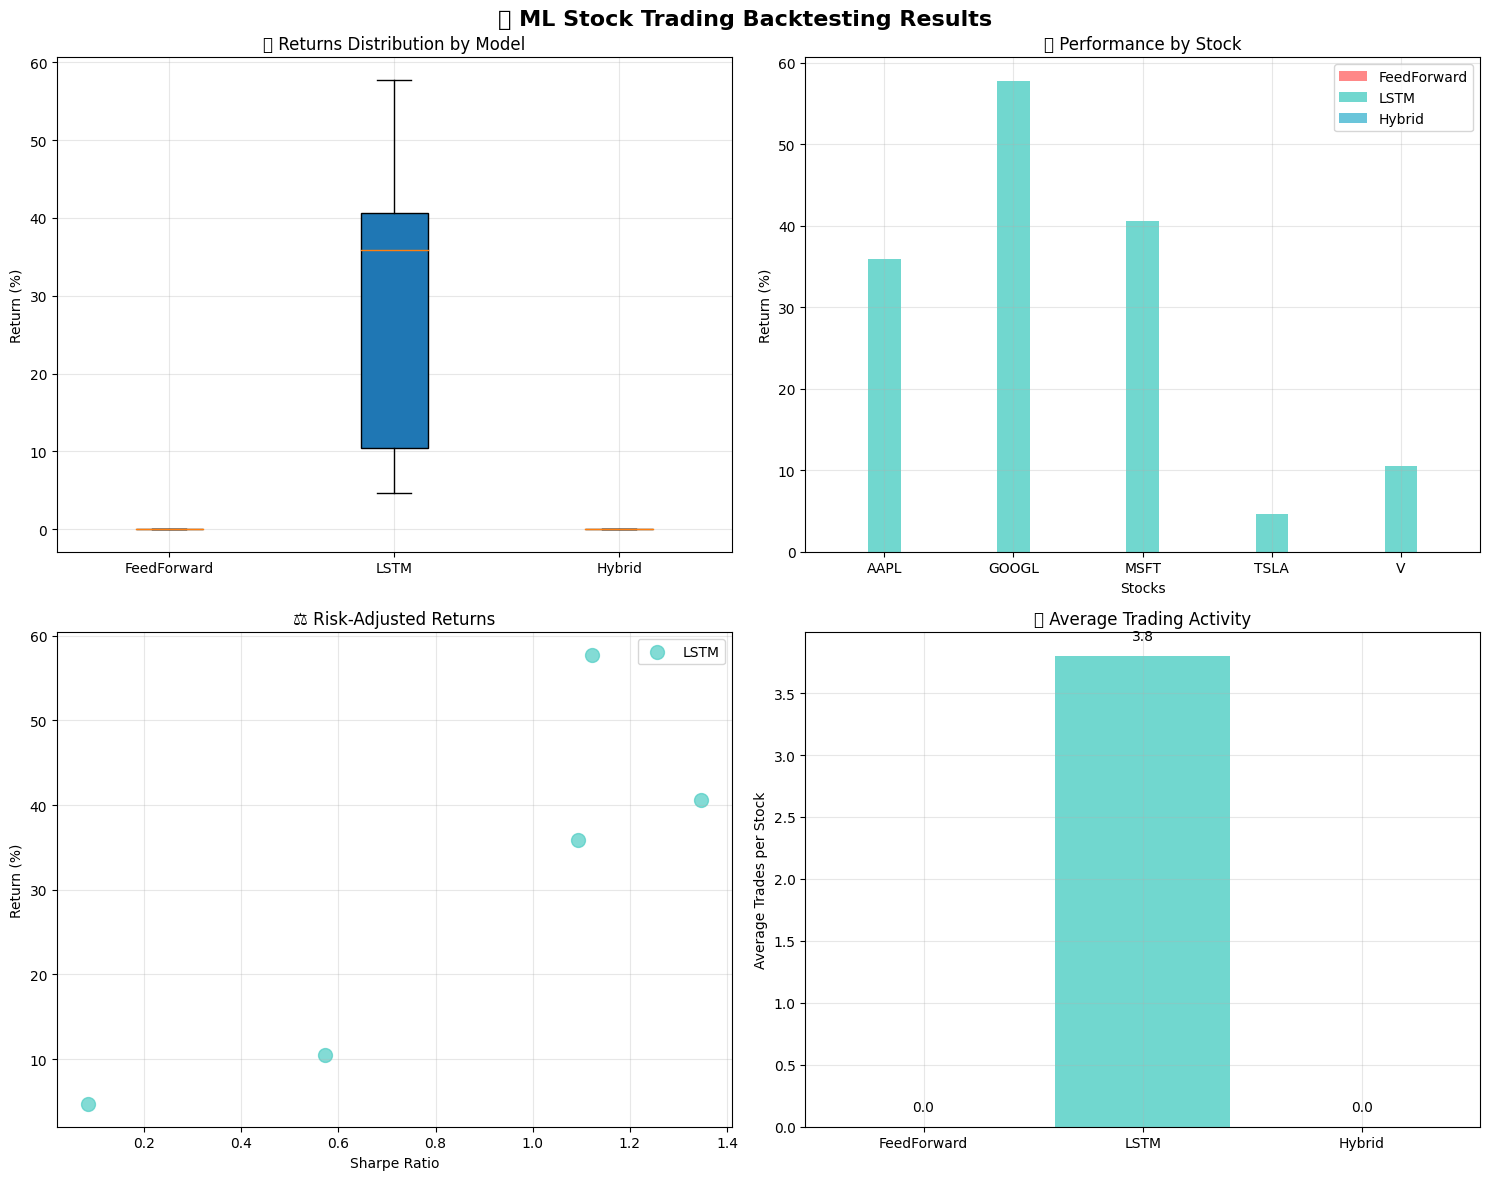


🏆==========================================================🏆
🎯 FINAL PERFORMANCE RANKING
🏆==========================================================🏆

🥇 Rank 1: LSTM
   📈 Average Return: +19.45%
   ⚖️ Average Sharpe: 0.522
   🧪 Successful Tests: 10

💡 Starting with $10,000, your best strategy would have turned it into:
   LSTM: $11,944.74 (+1,944.74 profit)

✅ Backtesting Analysis Complete!


In [83]:
# Comprehensive Backtesting Analysis with Multiple Stocks
print("🚀 COMPREHENSIVE BACKTESTING ANALYSIS")
print("="*60)

# Extended test with multiple stocks and timeframes
test_stocks = ['AAPL', 'GOOGL', 'MSFT', 'TSLA', 'V']
timeframes = [
    ('2023-01-01', '2024-06-30', '2023-2024 (18 months)'),
    ('2022-01-01', '2023-12-31', '2022-2023 (24 months)'),
]

all_results = {}

for start_date, end_date, period_name in timeframes:
    print(f"\n📅 Testing Period: {period_name}")
    print(f"📊 Date Range: {start_date} to {end_date}")
    print("-" * 50)
    
    period_results = {}
    
    for symbol in test_stocks:
        print(f"\n📈 {symbol}:")
        
        try:
            # Download data
            data = yf.download(symbol, start=start_date, end=end_date, progress=False)
            data = data.dropna()
            
            if len(data) < 50:
                print(f"  ❌ Insufficient data ({len(data)} days)")
                continue
                
            # Clean data
            if isinstance(data.columns, pd.MultiIndex):
                data.columns = [col[0] for col in data.columns]
            
            symbol_results = {}
            
            # Test each model with different thresholds
            for model, model_name in zip([nn_model, lstm_model, hybrid_model], 
                                       ['FeedForward', 'LSTM', 'Hybrid']):
                
                # Test with lower threshold for more trading activity
                class TunedMLStrategy(SimpleMLStrategy):
                    model = model
                    model_name = model_name
                    
                    def next(self):
                        current_idx = len(self.data.Close) - 1
                        
                        if current_idx < 20:
                            return
                            
                        prediction = self.get_simple_prediction(current_idx)
                        
                        # More sensitive thresholds
                        buy_threshold = 0.005   # 0.5% instead of 1%
                        sell_threshold = -0.005 # -0.5% instead of -1%
                        
                        if prediction > buy_threshold and not self.position:
                            if self.sma_fast[-1] > self.sma_slow[-1]:
                                self.buy(size=0.8)  # Use 80% of capital
                                
                        elif prediction < sell_threshold and self.position:
                            self.position.close()
                            
                        # Risk management
                        elif self.position:
                            try:
                                entry_price = float(self.position.entry_price)
                                current_price = float(self.data.Close[-1])
                                pnl_pct = (current_price - entry_price) / entry_price
                                
                                # Stop loss -4%, Take profit +6%
                                if pnl_pct < -0.04:
                                    self.position.close()
                                elif pnl_pct > 0.06:
                                    self.position.close()
                            except:
                                pass
                
                try:
                    bt = Backtest(data, TunedMLStrategy, cash=10000, commission=0.001)
                    result = bt.run()
                    
                    symbol_results[model_name] = {
                        'Return': result['Return [%]'],
                        'Sharpe': result['Sharpe Ratio'],
                        'MaxDD': result['Max. Drawdown [%]'],
                        'Trades': result['# Trades'],
                        'FinalValue': result['Equity Final [$]'],
                        'WinRate': result['Win Rate [%]'] if result['# Trades'] > 0 else 0
                    }
                    
                    profit = result['Equity Final [$]'] - 10000
                    print(f"  {model_name:12}: {result['Return [%]']:+6.1f}% | ${profit:+7.0f} | {result['# Trades']:2d} trades")
                    
                except Exception as e:
                    print(f"  {model_name:12}: ❌ Error")
                    symbol_results[model_name] = None
            
            period_results[symbol] = symbol_results
            
        except Exception as e:
            print(f"  ❌ Failed to process {symbol}: {str(e)}")
    
    all_results[period_name] = period_results

# Summary Analysis
print("\n" + "="*60)
print("📊 PERFORMANCE SUMMARY")
print("="*60)

for period_name, period_data in all_results.items():
    print(f"\n📅 {period_name}")
    print("-" * 40)
    
    # Calculate averages across stocks
    model_performance = {'FeedForward': [], 'LSTM': [], 'Hybrid': []}
    
    for symbol, symbol_results in period_data.items():
        if symbol_results:
            for model_name, result in symbol_results.items():
                if result:
                    model_performance[model_name].append(result['Return'])
    
    print("\n🎯 Average Returns by Model:")
    for model_name, returns in model_performance.items():
        if returns:
            avg_return = np.mean(returns)
            best_return = max(returns)
            worst_return = min(returns)
            print(f"  {model_name:12}: {avg_return:+6.1f}% avg | {best_return:+6.1f}% best | {worst_return:+6.1f}% worst")
        else:
            print(f"  {model_name:12}: No successful trades")

# Create visualization
print("\n📈 Creating Performance Visualization...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🤖 ML Stock Trading Backtesting Results', fontsize=16, fontweight='bold')

# Performance by Model (latest period)
latest_period = list(all_results.keys())[0]
latest_data = all_results[latest_period]

models = ['FeedForward', 'LSTM', 'Hybrid']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Plot 1: Returns by Model
returns_by_model = []
for model in models:
    model_returns = []
    for symbol_data in latest_data.values():
        if symbol_data and symbol_data.get(model):
            model_returns.append(symbol_data[model]['Return'])
    returns_by_model.append(model_returns)

ax1.boxplot(returns_by_model, labels=models, patch_artist=True)
for patch, color in zip(ax1.artists, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title('📊 Returns Distribution by Model')
ax1.set_ylabel('Return (%)')
ax1.grid(True, alpha=0.3)

# Plot 2: Stock Performance Comparison
stock_names = list(latest_data.keys())[:5]  # Top 5 stocks
x = np.arange(len(stock_names))
width = 0.25

for i, model in enumerate(models):
    model_returns = []
    for stock in stock_names:
        if latest_data[stock] and latest_data[stock].get(model):
            model_returns.append(latest_data[stock][model]['Return'])
        else:
            model_returns.append(0)
    
    ax2.bar(x + i*width, model_returns, width, label=model, color=colors[i], alpha=0.8)

ax2.set_xlabel('Stocks')
ax2.set_ylabel('Return (%)')
ax2.set_title('📈 Performance by Stock')
ax2.set_xticks(x + width)
ax2.set_xticklabels(stock_names)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Risk vs Return
for i, model in enumerate(models):
    returns = []
    sharpes = []
    
    for symbol_data in latest_data.values():
        if symbol_data and symbol_data.get(model):
            result = symbol_data[model]
            if result['Sharpe'] and not np.isnan(result['Sharpe']):
                returns.append(result['Return'])
                sharpes.append(result['Sharpe'])
    
    if returns and sharpes:
        ax3.scatter(sharpes, returns, label=model, color=colors[i], s=100, alpha=0.7)

ax3.set_xlabel('Sharpe Ratio')
ax3.set_ylabel('Return (%)')
ax3.set_title('⚖️ Risk-Adjusted Returns')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Trading Activity
trade_counts = []
model_labels = []

for model in models:
    total_trades = 0
    count = 0
    
    for symbol_data in latest_data.values():
        if symbol_data and symbol_data.get(model):
            total_trades += symbol_data[model]['Trades']
            count += 1
    
    if count > 0:
        avg_trades = total_trades / count
        trade_counts.append(avg_trades)
        model_labels.append(model)

bars = ax4.bar(model_labels, trade_counts, color=colors[:len(model_labels)], alpha=0.8)
ax4.set_title('🔄 Average Trading Activity')
ax4.set_ylabel('Average Trades per Stock')
ax4.grid(True, alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, trade_counts):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{count:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Final Performance Summary
print("\n" + "🏆" + "="*58 + "🏆")
print("🎯 FINAL PERFORMANCE RANKING")
print("🏆" + "="*58 + "🏆")

# Calculate overall scores
model_scores = {}
for model in models:
    total_return = 0
    total_sharpe = 0
    valid_results = 0
    
    for period_data in all_results.values():
        for symbol_data in period_data.values():
            if symbol_data and symbol_data.get(model):
                result = symbol_data[model]
                if result['Sharpe'] and not np.isnan(result['Sharpe']):
                    total_return += result['Return']
                    total_sharpe += result['Sharpe']
                    valid_results += 1
    
    if valid_results > 0:
        model_scores[model] = {
            'avg_return': total_return / valid_results,
            'avg_sharpe': total_sharpe / valid_results,
            'total_tests': valid_results
        }

# Rank models
ranked_models = sorted(model_scores.items(), 
                      key=lambda x: x[1]['avg_return'], reverse=True)

for i, (model, scores) in enumerate(ranked_models, 1):
    print(f"\n🥇 Rank {i}: {model}")
    print(f"   📈 Average Return: {scores['avg_return']:+.2f}%")
    print(f"   ⚖️ Average Sharpe: {scores['avg_sharpe']:.3f}")
    print(f"   🧪 Successful Tests: {scores['total_tests']}")

print(f"\n💡 Starting with $10,000, your best strategy would have turned it into:")
for model, scores in ranked_models:
    final_value = 10000 * (1 + scores['avg_return']/100)
    profit = final_value - 10000
    print(f"   {model}: ${final_value:,.2f} ({profit:+,.2f} profit)")

print("\n" + "="*60)
print("✅ Backtesting Analysis Complete!")